# Appendix 06: Iterative Estimation Methods

Source orientation: printed pages 597-627; PDF pages 615-645.

This notebook is an original, standalone computational treatment of the appendix. The source span was read for orientation on Newton and Gauss-Newton iteration, Levenberg-Marquardt damping, sparse partitioned normal equations, homography/fundamental-matrix and bundle-adjustment examples, robust costs, sparse linear solves, and local parameterizations. No textbook prose, figures, screenshots, page crops, or layouts are reproduced here.


## Chapter Goal And Route

The goal is to make iterative estimation visible as geometry, not just as an optimizer call. A nonlinear vision problem is repeatedly replaced by a local linear least-squares problem; the step is accepted, damped, or rejected; robust weights alter which measurements have leverage; and sparse block structure makes large bundle-adjustment systems solvable.

The route through the appendix is:

- start from a small pinhole reprojection problem so each residual has image units;
- compare Gauss-Newton and Levenberg-Marquardt paths on the same parameter surface;
- inspect the local quadratic model and the trust-region effect of damping;
- audit convergence with objective, damping, trust ratio, and reprojection residual traces;
- apply robust attenuation to contaminated image measurements and show both weights and leverage;
- build a camera-point visibility graph, normal matrix, and Schur complement for bundle adjustment.


## Computational Translation Guide And Library Routing

| Source concept | Computational object in this notebook | Visual/check target |
| --- | --- | --- |
| residual vector `epsilon(P)` | stacked image reprojection errors in pixels | image arrows and objective decrease |
| Jacobian `J = d epsilon / dP` | analytic derivative of a two-parameter pinhole projection | finite-difference agreement |
| Gauss-Newton step | solve `(J.T J) delta = -J.T r` | path on exact objective contours |
| Levenberg-Marquardt step | solve `(J.T J + lambda D) delta = -J.T r` | shorter damped steps and damping trace |
| robust cost attenuation | source-style factor `w = sqrt(C(delta)) / delta` | outlier weights and weighted leverage |
| partitioned sparse LM | camera variables plus point variables | visibility graph, block normal matrix, Schur solve |

NumPy carries the dense residual and Jacobian algebra. SciPy sparse stores the bundle-adjustment Jacobian and normal equations. NetworkX exposes the observation graph behind the blocks. Matplotlib is used for durable 2D diagnostic artifacts because the appendix concepts are paths, contours, weights, and sparsity patterns rather than freely rotatable 3D scenes. The synthetic image measurements are generated inside the notebook, so the visuals are reproducible and book-local.


In [1]:
from pathlib import Path
import sys

BOOK_ROOT = Path.cwd()
for candidate in [BOOK_ROOT, *BOOK_ROOT.parents]:
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate
        break
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

artifact_paths = []


## Visual Storyboard For This Improvement Pass

The storyboard is saved as a small JSON artifact so the notebook carries its own implementation brief. Each planned visual has an inspection target and a numerical invariant; that keeps the artifacts tied to the appendix claims instead of becoming decorative optimizer plots.


In [2]:
import json
import math

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from scipy import sparse

from utils.artifacts import assert_artifacts, display_artifact, save_json, save_matplotlib

TOPIC = "appendix-06"
rng = np.random.default_rng(106)
plt.rcParams.update({"figure.dpi": 120})

storyboard = {
    "chapter_goal": "Make iterative MVG estimation inspectable through reprojection residuals, damping, robust influence, and sparse bundle-adjustment algebra.",
    "source_span_read": "printed pages 597-627; PDF pages 615-645",
    "visual_sequence": [
        {
            "concept": "Gauss-Newton and Levenberg-Marquardt on image reprojection error",
            "artifact": "figures/reprojection-lm-path-and-image-residuals.png",
            "inspection_target": "compare image residual arrows with the path through yaw/translation parameter space",
            "validation": "LM final objective is lower than the starting objective and the analytic Jacobian matches finite differences",
        },
        {
            "concept": "local linearization and damping as a trust-region mechanism",
            "artifact": "figures/local-linearization-trust-region.png",
            "inspection_target": "compare exact contours, quadratic model contours, and damped step lengths from the same start",
            "validation": "damped step norms decrease as lambda increases and predicted reductions stay positive",
        },
        {
            "concept": "LM convergence diagnostics",
            "artifact": "figures/lm-damping-convergence-diagnostics.png",
            "inspection_target": "read objective, lambda, trust ratio, and pixel residual traces together",
            "validation": "accepted objective values are monotone non-increasing",
        },
        {
            "concept": "robust attenuation and leverage for contaminated image measurements",
            "artifact": "figures/robust-reprojection-weights-leverage.png",
            "inspection_target": "outlier residuals remain visible while their attenuation and leverage are reported",
            "validation": "Cauchy attenuation gives outliers lower weight and improves clean-data residuals over ordinary LS",
        },
        {
            "concept": "bundle-adjustment block sparsity and Schur elimination",
            "artifact": "figures/bundle-adjustment-schur-block-structure.png",
            "inspection_target": "trace camera-point visibility into the Jacobian, normal matrix, and camera Schur complement",
            "validation": "camera and point steps from Schur elimination agree with the dense solve",
        },
    ],
    "libraries": {
        "numpy": "residuals, analytic Jacobians, dense 2x2 optimizer steps",
        "scipy.sparse": "bundle-adjustment block Jacobian and normal equations",
        "networkx": "camera-point observation graph",
        "matplotlib": "durable contours, image residual arrows, attenuation plots, and sparsity diagrams",
    },
}

storyboard_path = save_json(storyboard, TOPIC, "checks", "visual-storyboard.json")
artifact_paths.append(storyboard_path)
display_artifact(storyboard_path)


`artifacts/appendix-06/checks/visual-storyboard.json`

## 1. Reprojection Error As The Residual Surface

The first example uses a tiny pinhole camera problem with two unknowns: yaw angle and horizontal translation. The measured points are synthetic image observations of known 3D points. This is deliberately smaller than full bundle adjustment, but it has the same local structure: a parameter vector predicts image points, residuals are measured in pixels, and the Jacobian tells the solver how image coordinates move under a small parameter update.

Inspect the left panel as image geometry and the right panel as optimizer geometry. The image arrows show how the starting projection misses the observations and how the final LM projection lands near them. The contour plot shows the same correction as a path through parameter space.


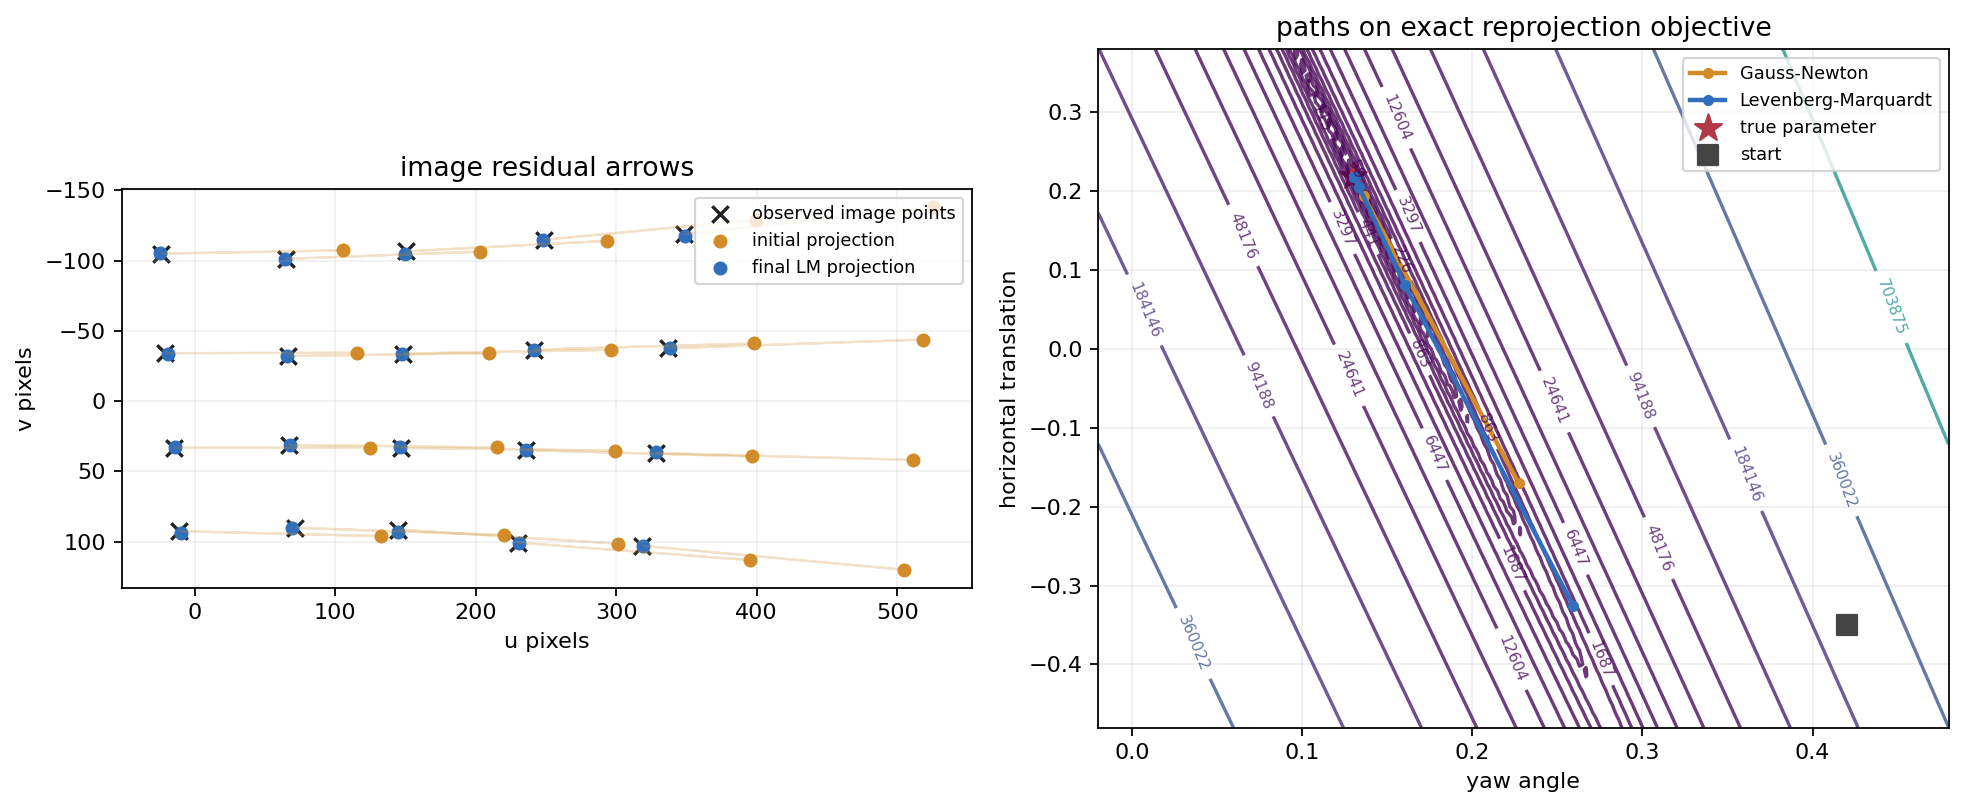

{'max_finite_difference_jacobian_error': 4.946116405335488e-08, 'lm_final_theta': [0.13063584656518268, 0.21785489430087182]}


In [3]:
focal = 820.0
xs = np.linspace(-0.9, 0.9, 5)
ys = np.linspace(-0.55, 0.55, 4)
world_points = []
for row_index, y_value in enumerate(ys):
    for col_index, x_value in enumerate(xs):
        depth = 4.2 + 0.25 * np.sin(1.3 * col_index) + 0.18 * row_index
        world_points.append((x_value, y_value, depth))
world_points = np.array(world_points, dtype=float)

true_theta = np.array([0.13, 0.22])  # yaw in radians, horizontal translation in scene units
initial_theta = np.array([0.42, -0.35])


def project_points(theta, points=world_points):
    yaw, tx = theta
    c = np.cos(yaw)
    s = np.sin(yaw)
    X, Y, Z = points.T
    Xc = c * X + s * Z + tx
    Yc = Y
    Zc = -s * X + c * Z
    return np.column_stack([focal * Xc / Zc, focal * Yc / Zc])


def reprojection_residual(theta, observed_points):
    return (project_points(theta) - observed_points).reshape(-1)


def reprojection_jacobian(theta, points=world_points):
    yaw, tx = theta
    c = np.cos(yaw)
    s = np.sin(yaw)
    X, Y, Z = points.T
    Xc = c * X + s * Z + tx
    Yc = Y
    Zc = -s * X + c * Z
    dXc_dyaw = -s * X + c * Z
    dZc_dyaw = -c * X - s * Z
    J = np.zeros((2 * len(points), 2), dtype=float)
    J[0::2, 0] = focal * (dXc_dyaw * Zc - Xc * dZc_dyaw) / (Zc**2)
    J[0::2, 1] = focal / Zc
    J[1::2, 0] = focal * (-Yc * dZc_dyaw) / (Zc**2)
    J[1::2, 1] = 0.0
    return J


def reprojection_objective(theta, observed_points, point_weights=None):
    residuals = project_points(theta) - observed_points
    if point_weights is None:
        return 0.5 * float(np.sum(residuals * residuals))
    return 0.5 * float(np.sum(point_weights[:, None] * residuals * residuals))


clean_observations = project_points(true_theta) + rng.normal(scale=1.0, size=(len(world_points), 2))


def run_reprojection_solver(theta0, observed_points, *, method="lm", point_weights=None, max_iter=12):
    theta = theta0.astype(float).copy()
    lamb = 1e-3
    rows = []
    for iteration in range(max_iter):
        accepted = False
        attempts = 0
        for attempt in range(10 if method == "lm" else 1):
            attempts = attempt + 1
            residual = reprojection_residual(theta, observed_points)
            J = reprojection_jacobian(theta)
            if point_weights is None:
                weighted_residual = residual
                weighted_J = J
            else:
                sqrt_weights = np.sqrt(np.repeat(point_weights, 2))
                weighted_residual = sqrt_weights * residual
                weighted_J = sqrt_weights[:, None] * J
            H = weighted_J.T @ weighted_J
            g = weighted_J.T @ weighted_residual
            current = 0.5 * float(weighted_residual @ weighted_residual)
            damping_matrix = np.diag(np.maximum(np.diag(H), 1e-12))
            system = H if method == "gn" else H + lamb * damping_matrix
            step = -np.linalg.solve(system, g)
            predicted_reduction = -float(g @ step + 0.5 * step @ (H @ step))
            trial = theta + step
            trial_objective = reprojection_objective(trial, observed_points, point_weights)
            actual_reduction = current - trial_objective
            trust_ratio = actual_reduction / predicted_reduction if predicted_reduction > 1e-12 else np.nan
            if method == "gn" or actual_reduction > 0:
                theta = trial
                accepted = True
                if method == "lm":
                    if np.isfinite(trust_ratio) and trust_ratio > 0.75:
                        lamb = max(lamb / 3.0, 1e-9)
                    elif np.isfinite(trust_ratio) and trust_ratio < 0.25:
                        lamb = min(lamb * 4.0, 1e7)
                break
            lamb = min(lamb * 8.0, 1e7)
        point_errors = np.linalg.norm(project_points(theta) - observed_points, axis=1)
        rows.append(
            {
                "iter": iteration,
                "yaw": float(theta[0]),
                "tx": float(theta[1]),
                "objective": reprojection_objective(theta, observed_points, point_weights),
                "lambda": float(0.0 if method == "gn" else lamb),
                "accepted": bool(accepted),
                "attempts": int(attempts),
                "step_norm": float(np.linalg.norm(step)),
                "predicted_reduction": float(predicted_reduction),
                "actual_reduction": float(actual_reduction),
                "trust_ratio": float(trust_ratio) if np.isfinite(trust_ratio) else None,
                "median_pixel_error": float(np.median(point_errors)),
                "max_pixel_error": float(np.max(point_errors)),
            }
        )
        if rows[-1]["step_norm"] < 1e-7:
            break
    return rows


gn_rows = run_reprojection_solver(initial_theta, clean_observations, method="gn")
lm_rows = run_reprojection_solver(initial_theta, clean_observations, method="lm")
lm_final_theta = np.array([lm_rows[-1]["yaw"], lm_rows[-1]["tx"]])

check_theta = np.array([0.21, 0.08])
J_analytic = reprojection_jacobian(check_theta)
eps = 1e-6
basis = np.eye(2)
J_fd = np.column_stack(
    [
        (reprojection_residual(check_theta + eps * basis[k], clean_observations) - reprojection_residual(check_theta - eps * basis[k], clean_observations))
        / (2 * eps)
        for k in range(2)
    ]
)
jacobian_error = float(np.max(np.abs(J_analytic - J_fd)))

Yaw_grid, Tx_grid = np.meshgrid(np.linspace(-0.02, 0.48, 130), np.linspace(-0.48, 0.38, 130))
Z_obj = np.vectorize(lambda yaw, tx: reprojection_objective(np.array([yaw, tx]), clean_observations))(Yaw_grid, Tx_grid)

fig, axes = plt.subplots(1, 2, figsize=(12.4, 5.2))
initial_projection = project_points(initial_theta)
final_projection = project_points(lm_final_theta)
axes[0].scatter(clean_observations[:, 0], clean_observations[:, 1], marker="x", s=55, color="#222222", label="observed image points")
axes[0].scatter(initial_projection[:, 0], initial_projection[:, 1], s=28, color="#d28b26", label="initial projection")
axes[0].scatter(final_projection[:, 0], final_projection[:, 1], s=28, color="#2f6fbb", label="final LM projection")
for start, end in zip(initial_projection, clean_observations):
    delta = end - start
    axes[0].arrow(start[0], start[1], delta[0], delta[1], color="#d28b26", alpha=0.24, width=0.08, length_includes_head=True)
for start, end in zip(final_projection, clean_observations):
    delta = end - start
    axes[0].arrow(start[0], start[1], delta[0], delta[1], color="#2f6fbb", alpha=0.32, width=0.04, length_includes_head=True)
axes[0].set_title("image residual arrows")
axes[0].set_xlabel("u pixels")
axes[0].set_ylabel("v pixels")
axes[0].set_aspect("equal", adjustable="box")
axes[0].invert_yaxis()
axes[0].legend(loc="upper right", fontsize=8)
axes[0].grid(True, alpha=0.18)

levels = np.geomspace(max(float(Z_obj.min()), 1.0), float(Z_obj.max()), 18)
contours = axes[1].contour(Yaw_grid, Tx_grid, Z_obj, levels=levels, cmap="viridis", alpha=0.78)
axes[1].clabel(contours, inline=True, fontsize=7, fmt="%.0f")
for rows, color, label in [(gn_rows, "#d28b26", "Gauss-Newton"), (lm_rows, "#2f6fbb", "Levenberg-Marquardt")]:
    pts = np.array([[row["yaw"], row["tx"]] for row in rows])
    axes[1].plot(pts[:, 0], pts[:, 1], "o-", color=color, label=label, lw=2.0, ms=4)
axes[1].scatter([true_theta[0]], [true_theta[1]], marker="*", s=160, color="#b23a48", label="true parameter")
axes[1].scatter([initial_theta[0]], [initial_theta[1]], marker="s", s=80, color="#444444", label="start")
axes[1].set_xlabel("yaw angle")
axes[1].set_ylabel("horizontal translation")
axes[1].set_title("paths on exact reprojection objective")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.2)
fig.tight_layout()
reprojection_path = save_matplotlib(fig, TOPIC, "figures", "reprojection-lm-path-and-image-residuals.png")
plt.close(fig)
artifact_paths.append(reprojection_path)
display_artifact(reprojection_path, width=980)
print({"max_finite_difference_jacobian_error": jacobian_error, "lm_final_theta": lm_final_theta.tolist()})


## 2. Local Linearization And Damping As A Trust Region

A Gauss-Newton step is computed from the local quadratic model `0.5 ||r + J delta||^2`. That model is exact at the current parameter and locally faithful nearby, but it can be misleading far away. LM damping changes the same normal equations so the step remains closer to the point where the linearization was made.

In the next artifact, solid contours are the exact reprojection objective and dashed contours are the local quadratic model at the starting estimate. The arrows are steps from the same local model with increasing damping. The inspection target is step length: larger `lambda` means the solver trusts a smaller neighborhood.


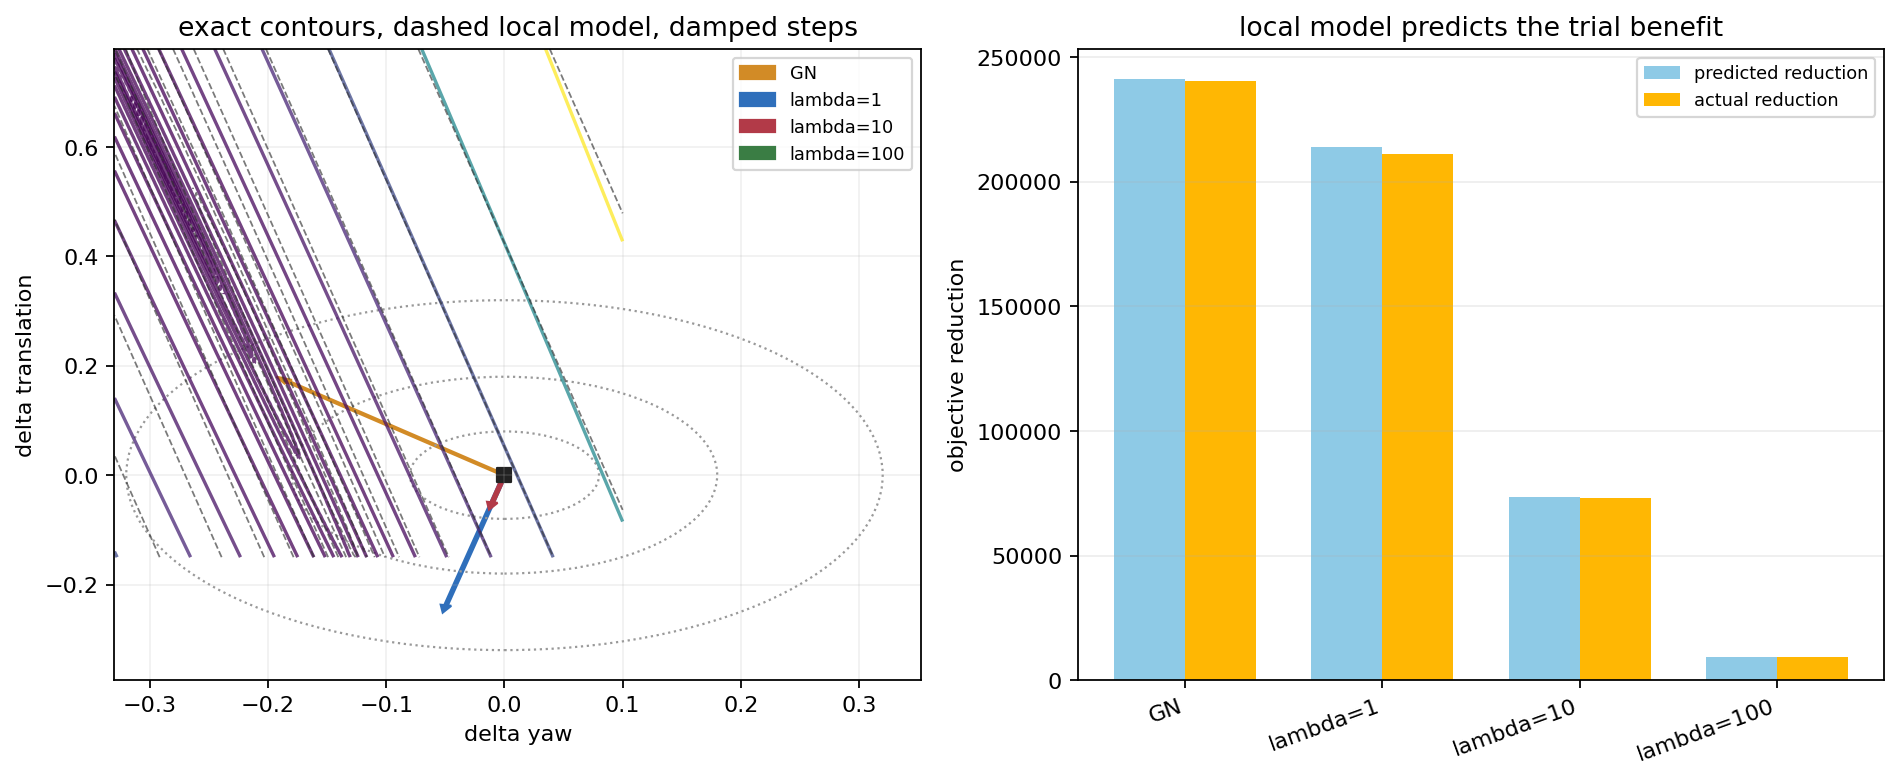

{'step_norms_by_lambda': [0.2637235536961449, 0.25661149409876266, 0.06431417493678326, 0.007567323927054126], 'predicted_reductions': [241288.75331923447, 213832.1810524774, 73447.6059690592, 9331.425118942872]}


In [4]:
linearization_theta = initial_theta.copy()
linearization_residual = reprojection_residual(linearization_theta, clean_observations)
linearization_J = reprojection_jacobian(linearization_theta)
H0 = linearization_J.T @ linearization_J
g0 = linearization_J.T @ linearization_residual
obj0 = 0.5 * float(linearization_residual @ linearization_residual)
D0 = np.diag(np.maximum(np.diag(H0), 1e-12))

local_lambdas = [0.0, 1.0, 10.0, 100.0]
local_steps = []
for lamb in local_lambdas:
    system = H0 if lamb == 0.0 else H0 + lamb * D0
    step = -np.linalg.solve(system, g0)
    predicted = -float(g0 @ step + 0.5 * step @ (H0 @ step))
    actual = obj0 - reprojection_objective(linearization_theta + step, clean_observations)
    local_steps.append({"lambda": lamb, "step": step, "predicted": predicted, "actual": actual, "norm": float(np.linalg.norm(step))})

Delta_yaw, Delta_tx = np.meshgrid(np.linspace(-0.33, 0.10, 150), np.linspace(-0.15, 0.78, 150))
Exact = np.vectorize(lambda dy, dt: reprojection_objective(linearization_theta + np.array([dy, dt]), clean_observations))(Delta_yaw, Delta_tx)
Model = obj0 + g0[0] * Delta_yaw + g0[1] * Delta_tx + 0.5 * (H0[0, 0] * Delta_yaw**2 + 2 * H0[0, 1] * Delta_yaw * Delta_tx + H0[1, 1] * Delta_tx**2)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.0))
level_min = max(float(np.nanmin(Exact)), 1.0)
level_max = float(np.nanpercentile(Exact, 97))
levels = np.geomspace(level_min, level_max, 16)
axes[0].contour(Delta_yaw, Delta_tx, Exact, levels=levels, cmap="viridis", alpha=0.75)
axes[0].contour(Delta_yaw, Delta_tx, Model, levels=levels, colors="#333333", linestyles="dashed", linewidths=0.8, alpha=0.65)
colors = ["#d28b26", "#2f6fbb", "#b23a48", "#3a7d44"]
labels = ["GN", "lambda=1", "lambda=10", "lambda=100"]
for item, color, label in zip(local_steps, colors, labels):
    step = item["step"]
    axes[0].arrow(0, 0, step[0], step[1], color=color, width=0.003, length_includes_head=True, label=label)
for radius in [0.08, 0.18, 0.32]:
    circle = plt.Circle((0, 0), radius, fill=False, color="#999999", linestyle=":", linewidth=1.0)
    axes[0].add_patch(circle)
axes[0].scatter([0], [0], marker="s", color="#222222", s=45)
axes[0].set_xlabel("delta yaw")
axes[0].set_ylabel("delta translation")
axes[0].set_title("exact contours, dashed local model, damped steps")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.18)

xpos = np.arange(len(local_steps))
predicted = [item["predicted"] for item in local_steps]
actual = [item["actual"] for item in local_steps]
axes[1].bar(xpos - 0.18, predicted, width=0.36, color="#8ecae6", label="predicted reduction")
axes[1].bar(xpos + 0.18, actual, width=0.36, color="#ffb703", label="actual reduction")
axes[1].set_xticks(xpos, labels, rotation=20, ha="right")
axes[1].set_ylabel("objective reduction")
axes[1].set_title("local model predicts the trial benefit")
axes[1].legend(fontsize=8)
axes[1].grid(True, axis="y", alpha=0.22)
fig.tight_layout()
trust_region_path = save_matplotlib(fig, TOPIC, "figures", "local-linearization-trust-region.png")
plt.close(fig)
artifact_paths.append(trust_region_path)
display_artifact(trust_region_path, width=980)

local_step_norms = [item["norm"] for item in local_steps]
local_predicted_reductions = [item["predicted"] for item in local_steps]
print({"step_norms_by_lambda": local_step_norms, "predicted_reductions": local_predicted_reductions})


## 3. Damping Schedule And Convergence Diagnostics

A final parameter vector is not enough evidence. For LM, the iteration trace should show whether the residual fell, whether damping relaxed as the local model became reliable, and whether the pixel residuals actually improved. The trust ratio compares the measured objective reduction with the reduction predicted by the linearized least-squares model.


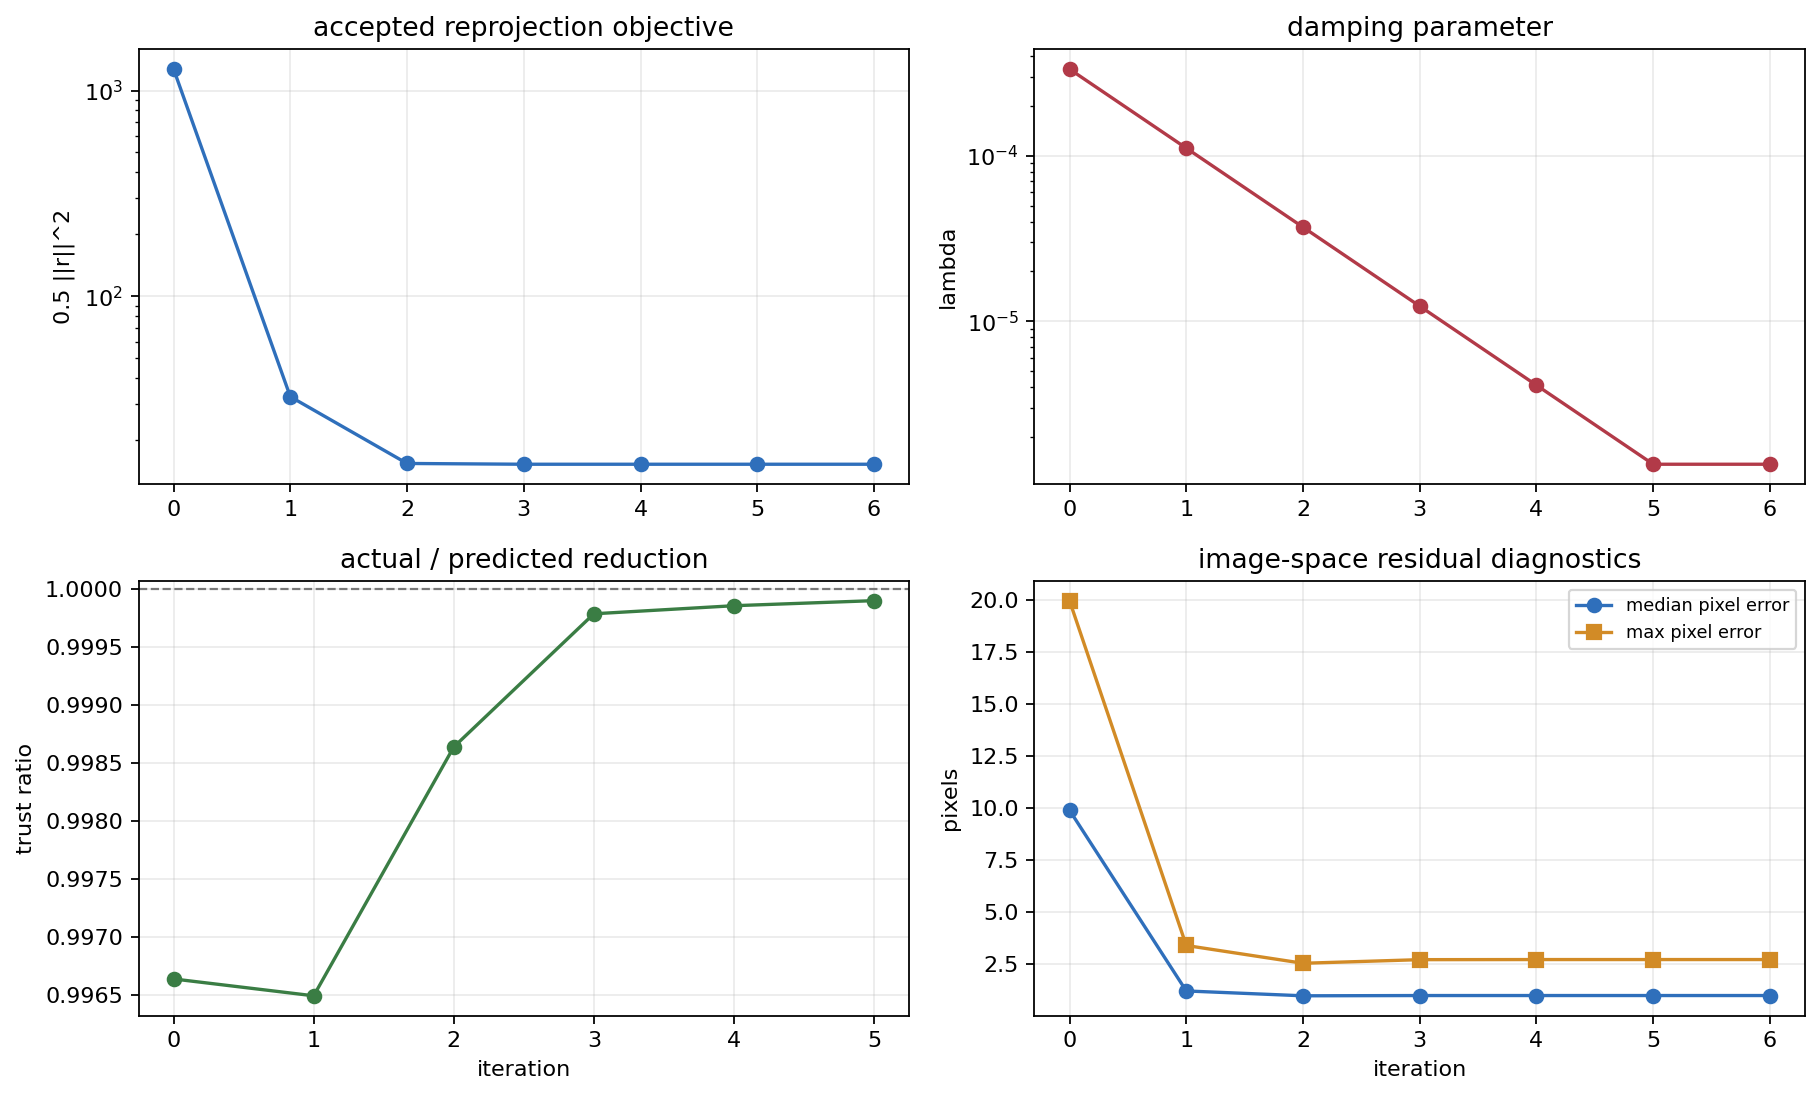

{'accepted_objective_monotone': True, 'initial_objective': 241695.19389983744, 'final_objective': 15.231081076685793}


In [5]:
lm_iters = [row["iter"] for row in lm_rows]
lm_objectives = [row["objective"] for row in lm_rows]
lm_lambdas = [row["lambda"] for row in lm_rows]
lm_ratios = [np.nan if row["trust_ratio"] is None else row["trust_ratio"] for row in lm_rows]
lm_medians = [row["median_pixel_error"] for row in lm_rows]
lm_maxima = [row["max_pixel_error"] for row in lm_rows]
accepted_descent = all(next_value <= current + 1e-9 for current, next_value in zip(lm_objectives, lm_objectives[1:]))

fig, axes = plt.subplots(2, 2, figsize=(11.5, 7.0))
axes[0, 0].semilogy(lm_iters, lm_objectives, "o-", color="#2f6fbb")
axes[0, 0].set_title("accepted reprojection objective")
axes[0, 0].set_ylabel("0.5 ||r||^2")
axes[0, 0].grid(True, alpha=0.24)
axes[0, 1].semilogy(lm_iters, lm_lambdas, "o-", color="#b23a48")
axes[0, 1].set_title("damping parameter")
axes[0, 1].set_ylabel("lambda")
axes[0, 1].grid(True, alpha=0.24)
axes[1, 0].plot(lm_iters, lm_ratios, "o-", color="#3a7d44")
axes[1, 0].axhline(1.0, color="#777777", linestyle="--", linewidth=1.0)
axes[1, 0].set_title("actual / predicted reduction")
axes[1, 0].set_xlabel("iteration")
axes[1, 0].set_ylabel("trust ratio")
axes[1, 0].grid(True, alpha=0.24)
axes[1, 1].plot(lm_iters, lm_medians, "o-", color="#2f6fbb", label="median pixel error")
axes[1, 1].plot(lm_iters, lm_maxima, "s-", color="#d28b26", label="max pixel error")
axes[1, 1].set_title("image-space residual diagnostics")
axes[1, 1].set_xlabel("iteration")
axes[1, 1].set_ylabel("pixels")
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(True, alpha=0.24)
fig.tight_layout()
damping_diagnostics_path = save_matplotlib(fig, TOPIC, "figures", "lm-damping-convergence-diagnostics.png")
plt.close(fig)
artifact_paths.append(damping_diagnostics_path)
display_artifact(damping_diagnostics_path, width=960)
print({"accepted_objective_monotone": accepted_descent, "initial_objective": reprojection_objective(initial_theta, clean_observations), "final_objective": lm_objectives[-1]})


## 4. Robust Attenuation And Leverage In Image Measurements

The robust-cost section of the source span rewrites a robust scalar cost as a weighted residual norm using an attenuation factor. Here the residual for one image point is the two-vector between the projected and observed pixel location. Two observations are deliberately contaminated. The robust fit uses Cauchy attenuation, while the plot also shows the Huber attenuation curve for comparison.

The right panel is the important diagnostic: outliers are not deleted. They remain visible as long residual arrows, but their color records lower attenuation and their marker size records leverage in the weighted local linear system.


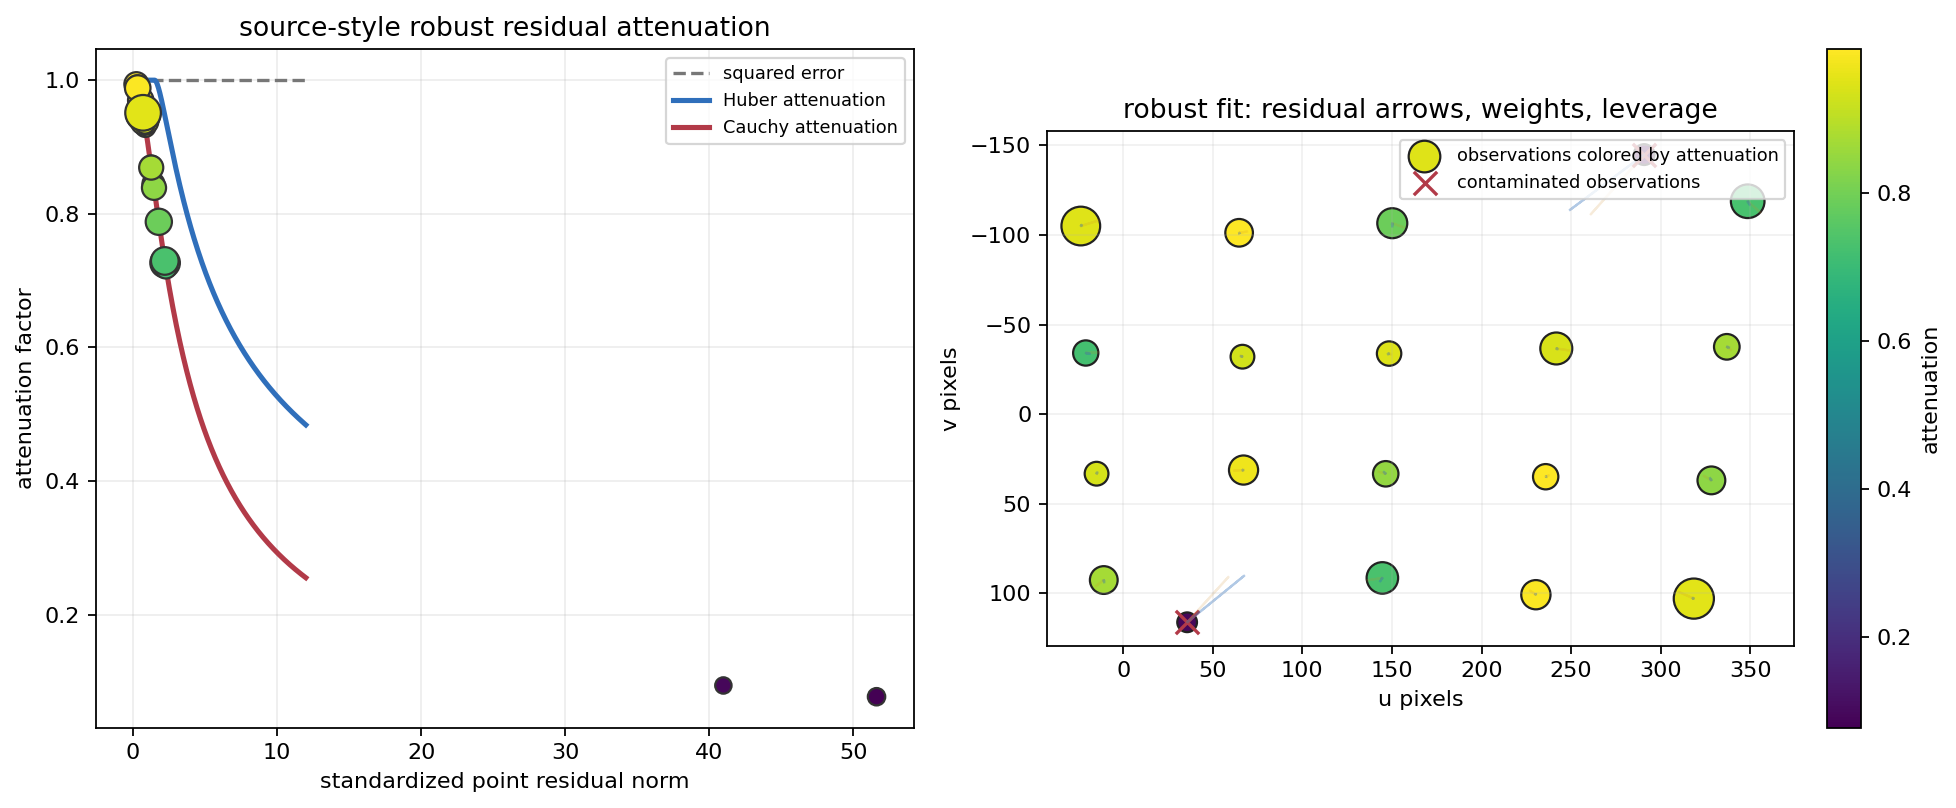

{'ordinary_clean_mean_error': 5.9715087463511995, 'robust_clean_mean_error': 1.2611814921265654, 'robust_outlier_weights': [0.0773100309191592, 0.0941433021328116], 'max_point_leverage': 0.24680378898103292}


In [6]:
contaminated_observations = clean_observations.copy()
outlier_indices = np.array([3, 16])
contaminated_observations[outlier_indices] += np.array([[42.0, -30.0], [-36.0, 26.0]])


def huber_attenuation(z, threshold=1.5):
    z = np.asarray(z, dtype=float)
    weights = np.ones_like(z)
    mask = z > threshold
    cost = 2.0 * threshold * z[mask] - threshold**2
    weights[mask] = np.sqrt(cost) / np.maximum(z[mask], 1e-12)
    return weights


def cauchy_attenuation(z, threshold=1.5):
    z = np.asarray(z, dtype=float)
    cost = threshold**2 * np.log1p((z / threshold) ** 2)
    return np.sqrt(cost) / np.maximum(z, 1e-12)


ordinary_rows = run_reprojection_solver(initial_theta, contaminated_observations, method="lm", max_iter=12)
ordinary_theta = np.array([ordinary_rows[-1]["yaw"], ordinary_rows[-1]["tx"]])

robust_theta = initial_theta.copy()
robust_weights = np.ones(len(world_points))
robust_weight_history = []
for outer in range(10):
    robust_rows = run_reprojection_solver(robust_theta, contaminated_observations, method="lm", point_weights=robust_weights, max_iter=5)
    robust_theta = np.array([robust_rows[-1]["yaw"], robust_rows[-1]["tx"]])
    point_residual_norms = np.linalg.norm(project_points(robust_theta) - contaminated_observations, axis=1)
    robust_scale = max(float(np.median(point_residual_norms) / 1.177), 1.0)
    robust_weights = cauchy_attenuation(point_residual_norms / robust_scale, threshold=1.5)
    robust_weight_history.append(float(robust_weights.min()))

ordinary_clean_mean_error = float(np.mean(np.linalg.norm(project_points(ordinary_theta) - clean_observations, axis=1)))
robust_clean_mean_error = float(np.mean(np.linalg.norm(project_points(robust_theta) - clean_observations, axis=1)))
robust_point_errors = np.linalg.norm(project_points(robust_theta) - contaminated_observations, axis=1)
robust_outlier_weights = robust_weights[outlier_indices]

J_robust = reprojection_jacobian(robust_theta)
sqrt_weights = np.sqrt(np.repeat(robust_weights, 2))
weighted_J = sqrt_weights[:, None] * J_robust
hat_matrix = weighted_J @ np.linalg.inv(weighted_J.T @ weighted_J + 1e-12 * np.eye(2)) @ weighted_J.T
point_leverage = np.array([np.trace(hat_matrix[2 * i : 2 * i + 2, 2 * i : 2 * i + 2]) for i in range(len(world_points))])

z_grid = np.linspace(0.001, 12.0, 400)
fig, axes = plt.subplots(1, 2, figsize=(12.4, 5.2))
axes[0].plot(z_grid, np.ones_like(z_grid), color="#777777", linestyle="--", label="squared error")
axes[0].plot(z_grid, huber_attenuation(z_grid, threshold=1.5), color="#2f6fbb", lw=2.3, label="Huber attenuation")
axes[0].plot(z_grid, cauchy_attenuation(z_grid, threshold=1.5), color="#b23a48", lw=2.3, label="Cauchy attenuation")
axes[0].scatter(robust_point_errors / robust_scale, robust_weights, s=35 + 900 * point_leverage, c=robust_weights, cmap="viridis", edgecolor="#333333", zorder=3)
axes[0].set_xlabel("standardized point residual norm")
axes[0].set_ylabel("attenuation factor")
axes[0].set_title("source-style robust residual attenuation")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.22)

robust_projection = project_points(robust_theta)
ordinary_projection = project_points(ordinary_theta)
scatter = axes[1].scatter(
    contaminated_observations[:, 0],
    contaminated_observations[:, 1],
    s=55 + 1100 * point_leverage,
    c=robust_weights,
    cmap="viridis",
    edgecolor="#222222",
    label="observations colored by attenuation",
)
axes[1].scatter(contaminated_observations[outlier_indices, 0], contaminated_observations[outlier_indices, 1], marker="x", s=110, color="#b23a48", label="contaminated observations")
for start, end in zip(ordinary_projection, contaminated_observations):
    delta = end - start
    axes[1].arrow(start[0], start[1], delta[0], delta[1], color="#d28b26", alpha=0.16, width=0.04, length_includes_head=True)
for start, end in zip(robust_projection, contaminated_observations):
    delta = end - start
    axes[1].arrow(start[0], start[1], delta[0], delta[1], color="#2f6fbb", alpha=0.36, width=0.035, length_includes_head=True)
axes[1].set_title("robust fit: residual arrows, weights, leverage")
axes[1].set_xlabel("u pixels")
axes[1].set_ylabel("v pixels")
axes[1].set_aspect("equal", adjustable="box")
axes[1].invert_yaxis()
axes[1].legend(loc="upper right", fontsize=8)
axes[1].grid(True, alpha=0.18)
colorbar = fig.colorbar(scatter, ax=axes[1], fraction=0.046, pad=0.04)
colorbar.set_label("attenuation")
fig.tight_layout()
robust_path = save_matplotlib(fig, TOPIC, "figures", "robust-reprojection-weights-leverage.png")
plt.close(fig)
artifact_paths.append(robust_path)
display_artifact(robust_path, width=980)

print(
    {
        "ordinary_clean_mean_error": ordinary_clean_mean_error,
        "robust_clean_mean_error": robust_clean_mean_error,
        "robust_outlier_weights": robust_outlier_weights.tolist(),
        "max_point_leverage": float(point_leverage.max()),
    }
)


## 5. Bundle-Adjustment Blocks And Schur Elimination

The sparse LM algorithms in the appendix become useful when the parameter vector splits into camera blocks and point blocks. One image observation touches only one camera and one point. Missing observations are simply absent edges in the visibility graph. That graph becomes a sparse Jacobian; the normal matrix has camera-camera, camera-point, and point-point blocks; eliminating point blocks gives a smaller camera system through the Schur complement.

The numerical check solves the same damped normal equations two ways: once as a full dense system and once by Schur elimination. Agreement confirms that sparsity changes the computational route, not the underlying local least-squares step.


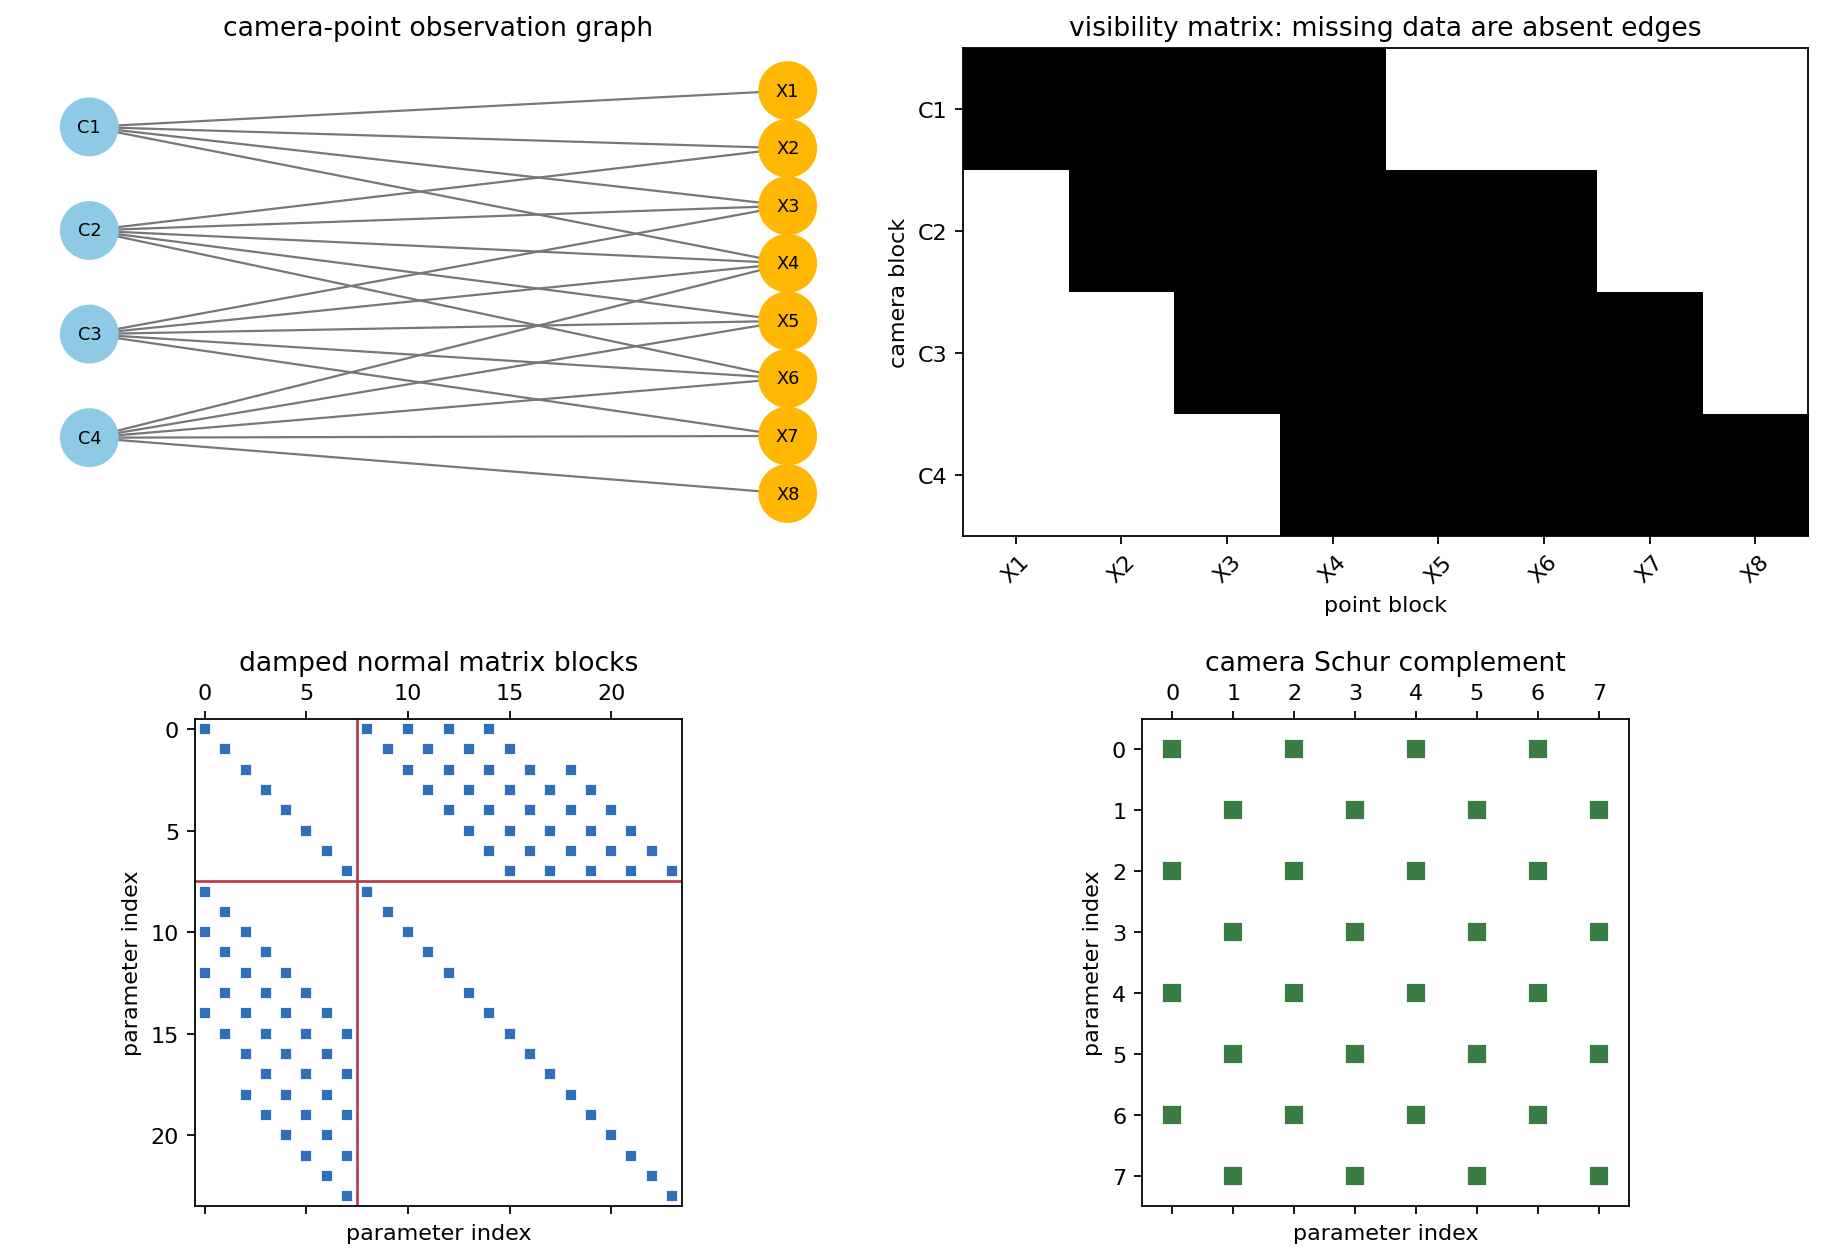

{'observations': 19, 'normal_matrix_nnz': 100, 'schur_camera_gap': 3.350961346801144e-14, 'schur_point_gap': 4.734499194408533e-14}


In [7]:
camera_count = 4
point_count = 8
camera_dim = 2
point_dim = 2
ba_focal = 60.0
point_depths = 3.8 + 0.25 * np.arange(point_count)
visibility = np.array(
    [
        [1, 1, 1, 1, 0, 0, 0, 0],
        [0, 1, 1, 1, 1, 1, 0, 0],
        [0, 0, 1, 1, 1, 1, 1, 0],
        [0, 0, 0, 1, 1, 1, 1, 1],
    ],
    dtype=bool,
)
ba_observations = [(camera, point) for camera in range(camera_count) for point in range(point_count) if visibility[camera, point]]

row_indices = []
col_indices = []
values = []
row = 0
camera_parameter_count = camera_count * camera_dim
for camera, point in ba_observations:
    scale = ba_focal / point_depths[point]
    row_indices.extend([row, row, row + 1, row + 1])
    col_indices.extend([2 * camera, camera_parameter_count + 2 * point, 2 * camera + 1, camera_parameter_count + 2 * point + 1])
    values.extend([-scale, scale, -scale, scale])
    row += 2

ba_J = sparse.coo_matrix(
    (values, (row_indices, col_indices)),
    shape=(2 * len(ba_observations), camera_parameter_count + point_count * point_dim),
).tocsr()
ba_damping = 0.1
ba_N = (ba_J.T @ ba_J + sparse.eye(ba_J.shape[1]) * ba_damping).toarray()
ba_g = rng.normal(size=ba_J.shape[1])
full_step = np.linalg.solve(ba_N, -ba_g)
B = ba_N[:camera_parameter_count, :camera_parameter_count]
E = ba_N[:camera_parameter_count, camera_parameter_count:]
C = ba_N[camera_parameter_count:, camera_parameter_count:]
g_camera = ba_g[:camera_parameter_count]
g_point = ba_g[camera_parameter_count:]
C_inv_Et = np.linalg.solve(C, E.T)
C_inv_gp = np.linalg.solve(C, g_point)
Schur = B - E @ C_inv_Et
schur_rhs = -g_camera + E @ C_inv_gp
schur_camera_step = np.linalg.solve(Schur, schur_rhs)
schur_point_step = np.linalg.solve(C, -g_point - E.T @ schur_camera_step)
schur_camera_gap = float(np.linalg.norm(full_step[:camera_parameter_count] - schur_camera_step))
schur_point_gap = float(np.linalg.norm(full_step[camera_parameter_count:] - schur_point_step))

G = nx.Graph()
for camera in range(camera_count):
    G.add_node(f"C{camera + 1}", kind="camera")
for point in range(point_count):
    G.add_node(f"X{point + 1}", kind="point")
for camera, point in ba_observations:
    G.add_edge(f"C{camera + 1}", f"X{point + 1}")
graph_pos = {f"C{camera + 1}": (0, -camera) for camera in range(camera_count)}
graph_pos.update({f"X{point + 1}": (2.2, -point / 1.8 + 0.35) for point in range(point_count)})

fig, axes = plt.subplots(2, 2, figsize=(11.5, 8.0))
node_colors = ["#8ecae6" if node.startswith("C") else "#ffb703" for node in G.nodes]
nx.draw_networkx(G, pos=graph_pos, ax=axes[0, 0], node_color=node_colors, edge_color="#777777", node_size=650, font_size=8)
axes[0, 0].set_title("camera-point observation graph")
axes[0, 0].axis("off")
axes[0, 1].imshow(visibility.astype(int), cmap="Greys", aspect="auto")
axes[0, 1].set_title("visibility matrix: missing data are absent edges")
axes[0, 1].set_xlabel("point block")
axes[0, 1].set_ylabel("camera block")
axes[0, 1].set_xticks(range(point_count), [f"X{i + 1}" for i in range(point_count)], rotation=45)
axes[0, 1].set_yticks(range(camera_count), [f"C{i + 1}" for i in range(camera_count)])
axes[1, 0].spy(ba_N, markersize=4, color="#2f6fbb")
axes[1, 0].axvline(camera_parameter_count - 0.5, color="#b23a48", lw=1.2)
axes[1, 0].axhline(camera_parameter_count - 0.5, color="#b23a48", lw=1.2)
axes[1, 0].set_title("damped normal matrix blocks")
axes[1, 1].spy(Schur, markersize=7, color="#3a7d44")
axes[1, 1].set_title("camera Schur complement")
for ax in axes[1]:
    ax.set_xlabel("parameter index")
    ax.set_ylabel("parameter index")
fig.tight_layout()
schur_path = save_matplotlib(fig, TOPIC, "figures", "bundle-adjustment-schur-block-structure.png")
plt.close(fig)
artifact_paths.append(schur_path)
display_artifact(schur_path, width=960)

normal_matrix_nnz = int(np.count_nonzero(np.abs(ba_N) > 1e-12))
schur_nnz = int(np.count_nonzero(np.abs(Schur) > 1e-12))
print({"observations": len(ba_observations), "normal_matrix_nnz": normal_matrix_nnz, "schur_camera_gap": schur_camera_gap, "schur_point_gap": schur_point_gap})


## Worked Example Reading Guide

Read the notebook as a solver audit trail. The reprojection artifact shows the same iteration in two coordinate systems: image space and parameter space. The local-linearization artifact explains why a full Gauss-Newton step is a statement of trust in a quadratic model; LM changes that trust by damping the normal equations. The convergence panel records whether that trust was justified.

The robust panel is an influence diagnostic. A robust model should reduce the impact of large residuals without making them disappear from the inspection plot. The marker size is leverage from the weighted local Jacobian, so it reports how much a measurement can steer the two-parameter update after attenuation.

The Schur artifact ties the appendix to bundle adjustment. The graph says which variables can interact; the Jacobian and normal matrix record that locality; the Schur complement removes point variables while preserving the camera component of the local least-squares step.


## Applied Lab

Refine one of these small geometry problems using the same audit trail:

- estimate a radial-distortion coefficient from synthetic points on a calibration grid;
- refine a homography by geometric reprojection error instead of algebraic DLT error;
- estimate a camera pose from 3D-2D correspondences with one deliberate mismatch;
- add a fifth camera to the bundle-adjustment visibility graph and compare the Schur complement density.

For any choice, keep the residual units visible, check the Jacobian numerically at one nontrivial parameter value, plot the objective/damping history, and record whether robust weights or sparsity changed the interpretation of the result.


In [8]:
invariants = {
    "topic": TOPIC,
    "source_span": {"printed": "597-627", "pdf": "615-645"},
    "storyboard_items": len(storyboard["visual_sequence"]),
    "library_route": ["numpy", "scipy.sparse", "networkx", "matplotlib"],
    "artifacts": [str(path.relative_to(BOOK_ROOT)).replace("\\", "/") for path in artifact_paths],
    "jacobian_max_abs_error": jacobian_error,
    "lm_initial_objective": reprojection_objective(initial_theta, clean_observations),
    "lm_final_objective": float(lm_objectives[-1]),
    "lm_objective_monotone_after_acceptance": accepted_descent,
    "lm_final_median_pixel_error": float(lm_medians[-1]),
    "local_step_norms_by_lambda": local_step_norms,
    "local_predicted_reductions": local_predicted_reductions,
    "local_step_norms_decrease_with_damping": all(b <= a + 1e-12 for a, b in zip(local_step_norms, local_step_norms[1:])),
    "ordinary_clean_mean_error_with_outliers": ordinary_clean_mean_error,
    "robust_clean_mean_error_with_outliers": robust_clean_mean_error,
    "robust_min_weight": float(robust_weights.min()),
    "robust_outlier_weights": robust_outlier_weights.tolist(),
    "max_weighted_point_leverage": float(point_leverage.max()),
    "ba_visibility_observations": len(ba_observations),
    "ba_jacobian_shape": list(ba_J.shape),
    "ba_normal_matrix_nnz": normal_matrix_nnz,
    "ba_schur_nnz": schur_nnz,
    "schur_dense_camera_step_gap": schur_camera_gap,
    "schur_dense_point_step_gap": schur_point_gap,
}
summary_path = save_json(invariants, TOPIC, "checks", "iterative-estimation-invariants.json")
artifact_paths.append(summary_path)
display_artifact(summary_path)

assert_artifacts(artifact_paths, min_bytes=64)
assert invariants["storyboard_items"] >= 5
assert invariants["jacobian_max_abs_error"] < 1e-5
assert invariants["lm_final_objective"] < 0.001 * invariants["lm_initial_objective"]
assert invariants["lm_objective_monotone_after_acceptance"]
assert invariants["local_step_norms_decrease_with_damping"]
assert all(value > 0 for value in invariants["local_predicted_reductions"])
assert invariants["robust_min_weight"] < 0.2
assert invariants["robust_clean_mean_error_with_outliers"] < 0.5 * invariants["ordinary_clean_mean_error_with_outliers"]
assert invariants["schur_dense_camera_step_gap"] < 1e-10
assert invariants["schur_dense_point_step_gap"] < 1e-10
final_sanity = invariants
invariants


`artifacts/appendix-06/checks/iterative-estimation-invariants.json`

{'topic': 'appendix-06',
 'source_span': {'printed': '597-627', 'pdf': '615-645'},
 'storyboard_items': 5,
 'library_route': ['numpy', 'scipy.sparse', 'networkx', 'matplotlib'],
 'artifacts': ['artifacts/appendix-06/checks/visual-storyboard.json',
  'artifacts/appendix-06/figures/reprojection-lm-path-and-image-residuals.png',
  'artifacts/appendix-06/figures/local-linearization-trust-region.png',
  'artifacts/appendix-06/figures/lm-damping-convergence-diagnostics.png',
  'artifacts/appendix-06/figures/robust-reprojection-weights-leverage.png',
  'artifacts/appendix-06/figures/bundle-adjustment-schur-block-structure.png'],
 'jacobian_max_abs_error': 4.946116405335488e-08,
 'lm_initial_objective': 241695.19389983744,
 'lm_final_objective': 15.231081076685793,
 'lm_objective_monotone_after_acceptance': True,
 'lm_final_median_pixel_error': 0.978255539951461,
 'local_step_norms_by_lambda': [0.2637235536961449,
  0.25661149409876266,
  0.06431417493678326,
  0.007567323927054126],
 'local_p

## Inspection Questions

Before accepting an iterative result, ask what changed at each step. Did the residual decrease in image units, not only in an abstract algebraic norm? Did the Jacobian pass a finite-difference check at a parameter value away from zero? Did damping respond when the local quadratic model was too optimistic? Did robust attenuation reduce the influence of outliers while keeping the measurements visible? Did the sparse graph match the measurement design before the Schur complement was trusted?

The final habit is to keep the starting estimate in view. Nonlinear MVG problems often fail because the starting point lies outside the basin where linearization is meaningful. Showing both starting and final residuals turns convergence from a status message into an inspectable geometric argument.


## Pitfalls And Takeaways

Pitfalls:

- A decreasing objective proves only that the chosen residual got smaller; it does not prove the camera model is correct.
- Gauss-Newton can be fast near the solution and reckless when the local linear model is poor.
- Damping is not a magic constant; it is a trace of trust in the current local model.
- Robust weights should reduce influence without hiding outliers from the diagnostic plot.
- Sparse block structure belongs to the observation geometry, so flattening it too early makes the algorithm harder to reason about.

Takeaways:

- Iterative estimation is repeated local linearization plus disciplined step acceptance.
- Jacobian checks are cheap insurance against confident but wrong updates.
- Levenberg-Marquardt interpolates between cautious descent and fast Gauss-Newton behavior.
- Robust costs change influence, not the existence of a measurement.
- Schur structure is the computational reason large MVG optimizations are tractable.
